# import

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
import seaborn as sns
from StatTools.generators.ndfnoise_generator import ndfnoise
from StatTools.generators.mfnoise_generator import mfnoise
from StatTools.visualization import plot_ff
from StatTools.analysis.dfa import DFA, dfa, dfa_worker
from StatTools.analysis.utils import(
    analyse_zero_cross_ff,
    analyse_cross_ff_linregress
) 

from joblib import Parallel, delayed, cpu_count
import plotly.express as px
from tqdm import tqdm
from scipy import stats
import matplotlib.pyplot as plt
from typing import Optional

# git clone https://github.com/Digiratory/FluctuationAnalysisTools.git
# cd FluctuationAnalysisTools
# mv StatTools/ ../

# defs

In [37]:
def frames_generator(field: np.ndarray):
    frames_num = field.shape[2]
    for i in range(frames_num):
        yield field[:,:,i]

In [38]:
def build_pyr(frame_list: list, levels:int):
    
    if levels==0:
        return frame_list
    else:

        scaled = cv.resize(src=frame_list[-1],
                           dsize=None,
                           dst=None,
                           fx=0.5,
                           fy=0.5,
                           interpolation=cv.INTER_CUBIC)
        frame_list.append(scaled)
        
        return build_pyr(frame_list, levels-1)

In [39]:
def farneback_optical_flows(field:np.ndarray,
                            pyr_level:int,
                            winsize: int = 15,
                            iterations: int = 5,
                            poly_n: int = 5,
                            poly_sigma: float = 1.1):
    
    frames_gen = frames_generator(field)

    ang_result      = [[] for _ in range(pyr_level+1)]
    mag_result      = [[] for _ in range(pyr_level+1)]
    x_shift_result  = [[] for _ in range(pyr_level+1)]
    y_shift_result  = [[] for _ in range(pyr_level+1)]

    try:
        prev_frame = next(frames_gen)
    except StopIteration:
        return None
    
    prev_pyr = build_pyr([prev_frame], pyr_level)

    for curr_frame in tqdm(iterable=frames_gen, total=field.shape[2]-1, desc='Field frames processing', unit='frames'):
        curr_pyr = build_pyr([curr_frame], pyr_level)
        
        for level in range(pyr_level+1):
            flow = cv.calcOpticalFlowFarneback(prev=prev_pyr[level],
                                               next=curr_pyr[level],
                                               flow=None,
                                               pyr_scale=0.5,
                                               levels=1,
                                               winsize=winsize,
                                               iterations=iterations,
                                               poly_n=poly_n,
                                               poly_sigma=poly_sigma,
                                               flags=0)
            
            # levels=1 means that no extra layers are created and only the original images are used.

            mag, ang = cv.cartToPolar(flow[..., 0], flow[..., 1])
            x_shift = flow[..., 0]
            y_shift = flow[..., 1]

            ang_result[level].append(ang)
            mag_result[level].append(mag)
            x_shift_result[level].append(x_shift)
            y_shift_result[level].append(y_shift)
        
        prev_pyr = curr_pyr
    
    ang_result      = [np.stack(level, axis=-1) for level in ang_result]
    mag_result      = [np.stack(level, axis=-1) for level in mag_result]
    x_shift_result  = [np.stack(level, axis=-1) for level in x_shift_result]
    y_shift_result  = [np.stack(level, axis=-1) for level in y_shift_result]

    return ang_result, mag_result, x_shift_result, y_shift_result


# generate field 

In [40]:
# задаемся параметрами поля
frame_num = 2048
frame_shape = (256, 256)
# получаем поле с заданным показателем херста
np.random.seed(42)
field = ndfnoise(shape=(*frame_shape, frame_num), hurst=1.2, normalize=True)

pyr_level = 5

In [41]:
def worker(series, n_integral, s_values):
    _, F2_s = dfa(dataset=series,
                  degree=2,
                  s_values=s_values,
                  processes=1,
                  n_integral=n_integral)
    return F2_s

s_min = 6
s_values = np.array([int(np.exp(step)) for step in np.arange(np.log(s_min), np.log(frame_num/4), 0.5)])
F2_s_field_result = []
h, w = field.shape[:2]

tasks = [field[i, j, :] for i in range(h) for j in range(w)]
n_tasks = len(tasks)

results = Parallel(n_jobs=12, backend='loky', verbose=0)(
    delayed(worker)(task, 1, s_values) for task in tqdm(tasks, desc=f'DFA calc', unit='series')
)


F2_s = np.array(results)
F_s = np.sqrt(F2_s)


DFA calc: 100%|██████████| 65536/65536 [01:24<00:00, 778.26series/s]


<Axes: >

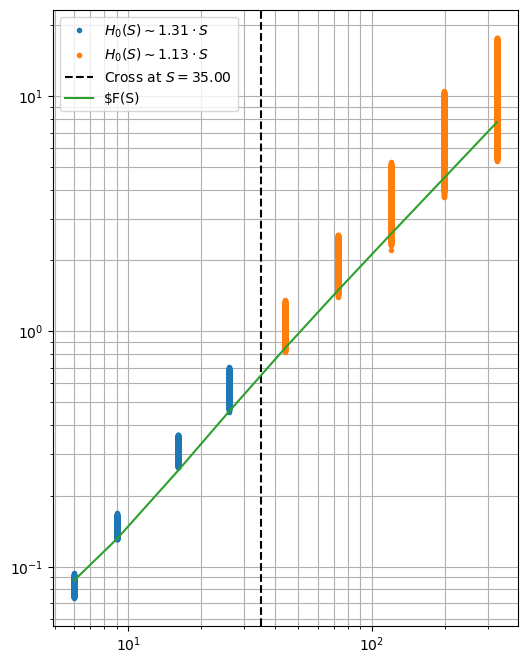

In [42]:

ff_params, _ = analyse_cross_ff_linregress(F_s, s_values)

fig, ax = plt.subplots(figsize=(6, 8))
plot_ff(
    F_s,
    s_values,
    ff_parameter=ff_params,
    residuals=None,
    ax=ax
)


<Axes: >

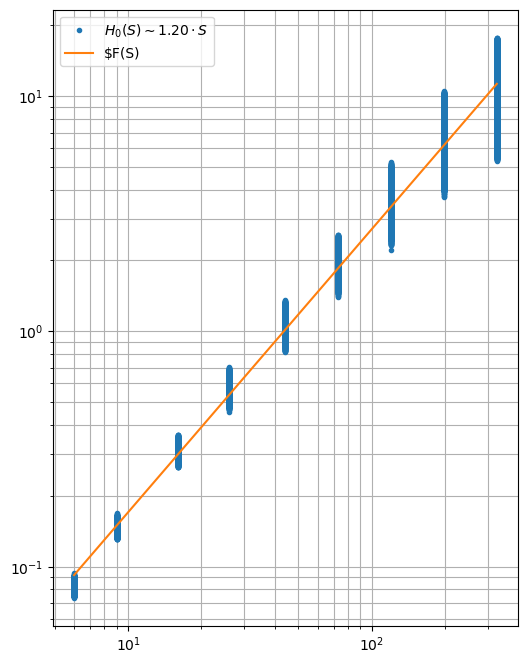

In [43]:
ff_params, _ = analyse_zero_cross_ff(F_s, s_values)

fig, ax = plt.subplots(figsize=(6, 8))
plot_ff(
    F_s,
    s_values,
    ff_parameter=ff_params,
    residuals=None,
    ax=ax
)


# calc optical flow

In [44]:
ang_result, mag_result, x_shift_result, y_shift_result = farneback_optical_flows(field=field, pyr_level=pyr_level)

Field frames processing: 100%|██████████| 2047/2047 [00:26<00:00, 76.41frames/s]


# dfa calc

In [45]:
n_jobs = cpu_count(only_physical_cores=True)

In [51]:
def worker(series, n_integral, s_values):
    _, F2_s = dfa(dataset=series,
                  degree=2,
                  s_values=s_values,
                  processes=1,
                  n_integral=n_integral)
    return F2_s


F_s_field_result = []

s_min = 6
s_values = np.array([int(np.exp(step)) for step in np.arange(np.log(s_min), np.log(frame_num/4), 0.5)])
n_integral=1
for level in range(pyr_level + 1):
    data_lvl = x_shift_result[level]
    h, w = data_lvl.shape[:2]
    
    tasks = [data_lvl[i, j, :] for i in range(h) for j in range(w)]
    n_tasks = len(tasks)
    
    results = Parallel(n_jobs=n_jobs, backend='loky', verbose=0)(
        delayed(worker)(task, n_integral, s_values) for task in tqdm(tasks, desc='DFA calc', unit='series')
    )
    
    
    F2_s_lvl = np.array(results)
    F_s_lvl = np.sqrt(F2_s_lvl)
    F_s_field_result.append(F_s_lvl)

DFA calc: 100%|██████████| 64/64 [00:00<00:00, 1931.33series/s]


# ff crossover analysis

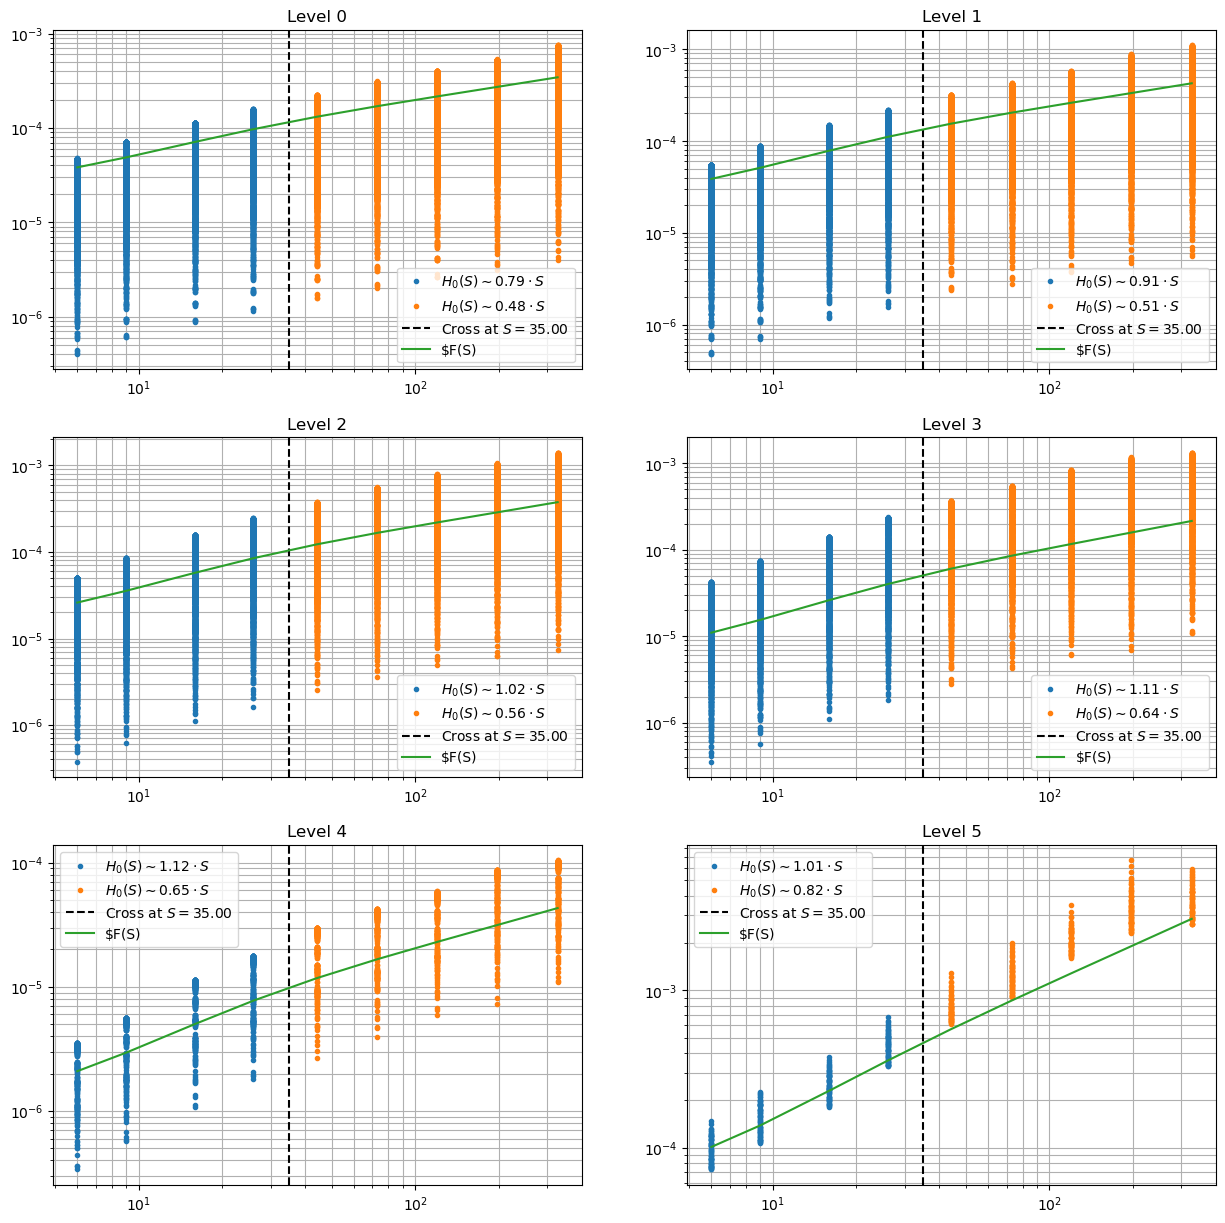

In [53]:
fig, axes = plt.subplots(nrows=len(F_s_field_result)//2, ncols=2, figsize=(15, 15))
axes = np.atleast_2d(axes).flatten()
for level, ax in enumerate(axes):

    data_lvl = F_s_field_result[level]
    ff_parameters, _ = analyse_cross_ff_linregress(data_lvl, s_values, min_window_size=4)

    plot_ff(
        data_lvl,
        s_values,
        ff_parameter=ff_parameters,
        residuals=None,
        ax=ax,
        title=f'Level {level}'
    )

# zero-cross ff

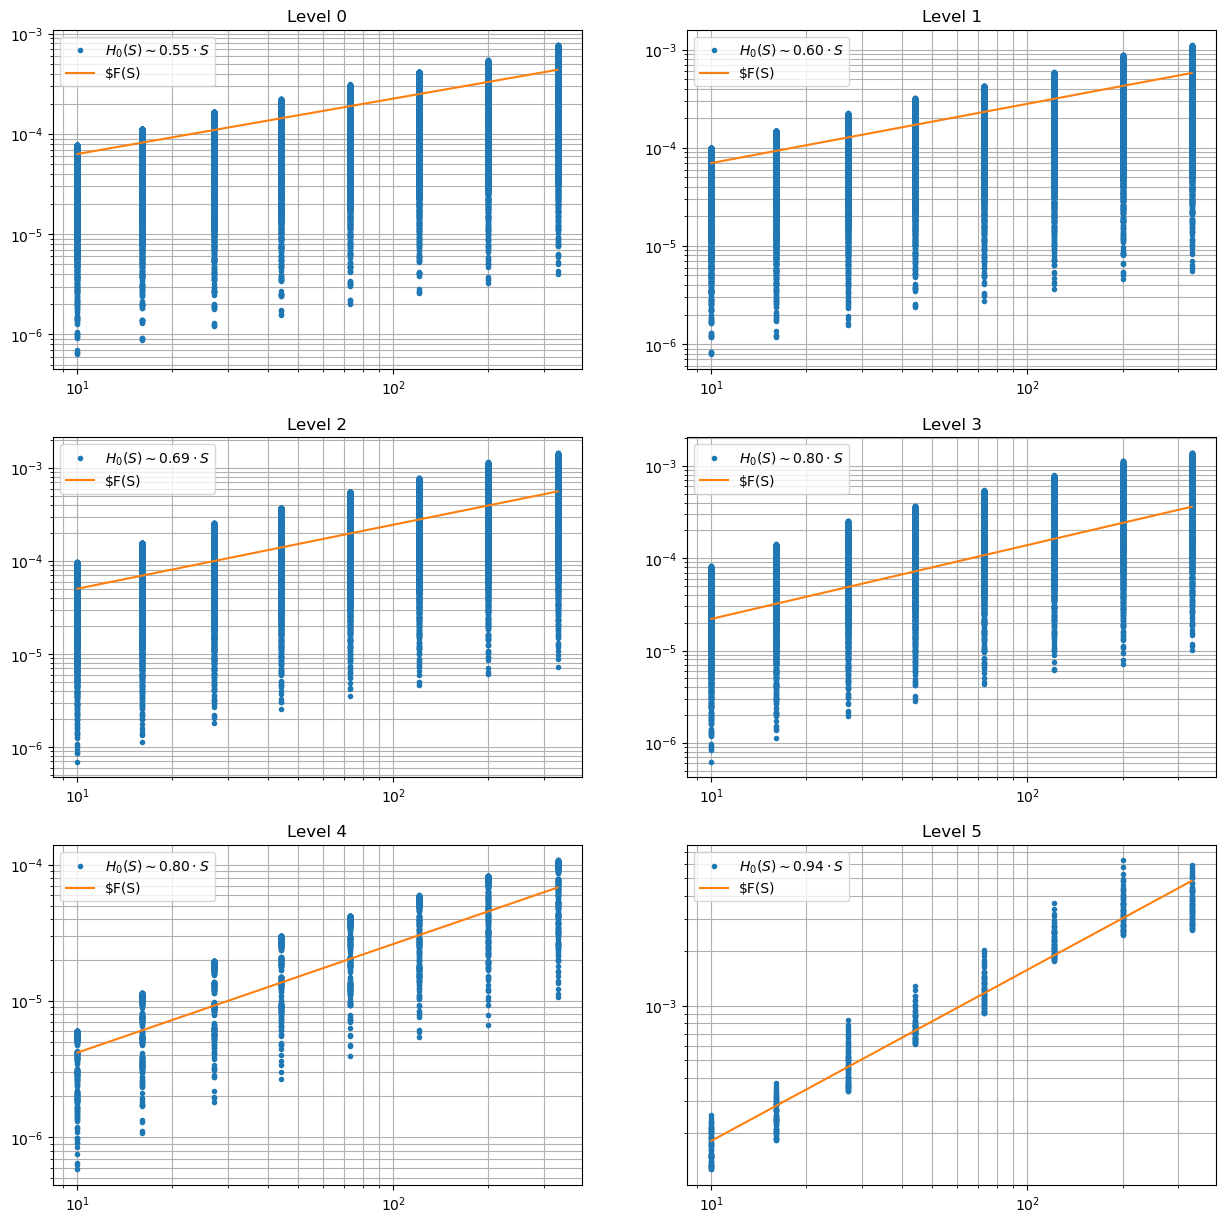

In [49]:
fig, axes = plt.subplots(nrows=len(F_s_field_result)//2, ncols=2, figsize=(15, 15))
axes = np.atleast_2d(axes).flatten()
for level, ax in enumerate(axes):

    data_lvl = F_s_field_result[level]
    ff_parameters, _ = analyse_zero_cross_ff(data_lvl, s_values)

    plot_ff(
        data_lvl,
        s_values,
        ff_parameter=ff_parameters,
        residuals=None,
        ax=ax,
        title=f'Level {level}'
    )

# field anime

In [ ]:
target = field[:,:, :150]
anime = px.imshow(target, color_continuous_scale ='inferno', animation_frame=2, width=500, height=500, zmin=target.min(), zmax=target.max())
anime.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 0
anime.show()